In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import pandas as pd

In [5]:
df = pd.read_csv(r"..\..\dataset\dataset_module_one_DM2.csv")

Starting Cross Validation with SMOTE and scaling...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

--- CV RESULTS ---
Best Params: {'svm__C': 1, 'svm__kernel': 'rbf'}
Best CV F1-Macro: 0.3136

--- TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

         0.0       0.79      0.65      0.72      1645
         1.0       0.25      0.31      0.28       413
         2.0       0.21      0.26      0.23       231
         3.0       0.03      0.24      0.05        21

    accuracy                           0.55      2310
   macro avg       0.32      0.37      0.32      2310
weighted avg       0.63      0.55      0.58      2310



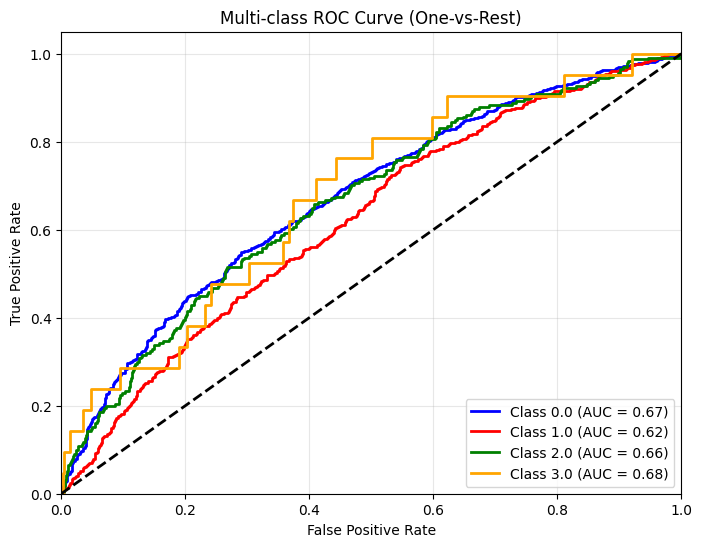

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report
# Use imblearn Pipeline to properly handle resampling during cross-validation
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 1. Split features and target
X = df.drop(columns=['sii'])
y = df['sii']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Setup SMOTE
smote_strategy = {
    1: 2000,  # Intermediate 1
    2: 2000,  # Intermediate 2
    3: 1500   # Minority class
}
smote = SMOTE(sampling_strategy=smote_strategy, random_state=42)

# 4. Create imblearn Pipeline (SMOTE + Scaling + Model)
pipeline = Pipeline([
    ('smote', smote),
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', probability=True))
])

# 5. Define Hyperparameters 
param_grid = {
    'svm__C': [1, 5, 10, 15, 20, 30],
    'svm__kernel': ['linear', 'rbf']
}

# 6. Grid Search Setup 
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

# 7. Execute Training
print("Starting Cross Validation with SMOTE and scaling...")
grid_search.fit(X_train, y_train)

# 8. Print Results
print("\n--- CV RESULTS ---")
print("Best Params:", grid_search.best_params_)
print("Best CV F1-Macro:", round(grid_search.best_score_, 4))

# 9. Evaluate on Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- TEST SET PERFORMANCE ---")
print(classification_report(y_test, y_pred))

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
classes = [0.0, 1.0, 2.0, 3.0]
y_test_bin = label_binarize(y_test, classes=classes)

# Get prediction probabilities
y_score = best_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']

for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, 
             label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()